# LSTM Autoencoder-based Anomaly Detection

___
## Introduction
This project is a personal practice attempt at performing anomaly detection on a multivariate time-series dataset. The dataset chosen is the Tennessee Eastman dataset, and anomalies in the data are detected through the reconstruction errors of an LSTM autoencoder.

In this approach, the autoencoder is first trained to reproduce the data of a 'normal' dataset. The assumption is that when anomalous data is later presented to the autoencoder, it would struggle to reproduce them and therefore higher reproduction/reconstruction errors would be incurred.
___
## The Tennessee Eastman Dataset
Source: https://www.kaggle.com/datasets/averkij/tennessee-eastman-process-simulation-dataset
- Download the dataset, and make sure the following four files are in the `./data/` directory
    - `TEP_FaultFree_Testing.RData`
    - `TEP_FaultFree_Training.RData`
    - `TEP_Faulty_Testing.RData`
    - `TEP_Faulty_Training.RData`

- More insight about the Tennessee Eastman Dataset can be found here:
    - https://keepfloyding.github.io/posts/Ten-East-Proc-Intro/
    - https://keepfloyding.github.io/posts/data-explor-TEP-1/
    - https://keepfloyding.github.io/posts/data-explor-TEP-2/
    - https://keepfloyding.github.io/posts/data-explor-TEP-3/


___
## Overview of Code
The essential code are found in the `src` directory.
- `datapipeline.py`: Functions for loading the Tennessee Eastman dataset and preparing the data for the autoencoder. Key parameters are loaded from `./configs/config.yaml`.
- `autoencoder.py`: Definitions of the encoder, decoder and autoencoder classes
- `ae_utils.py`: Functions for building, training, saving, loading, and inferencing from the autoencoder.
- `eval_tools.py`: Definition of an evaluator class specially designed for the autoencoder's anomaly detection performance on the Tennessee Eastman dataset.

Example of how the code can be used for anomaly detection is shown in the following section.

If adapting the LSTM autoencoder for other datasets or for other purpose, `autoencoder.py` and `ae_utils.py` can probably be reused with minimal modification. 

___
## Anomaly Detection Process
This process detects anomalies based on the reconstruction errors of the autoencoder (AE). Since the dataset is a time-series dataset, the AE will be a LSTM AE.

We will be training the AE with just the fault-free training dataset to establish what normal data should look like.

The AE will then be tested through the reconstruction of data from both the fault-free and faulty testing datasets.

### 1. Load Training Data

In [1]:
from src.datapipeline import load_train_data
from src.general_utils import load_config

config = load_config('./configs/config.yaml')
X_train_df, X_val_df, dl_train, dl_val, scaler = load_train_data(config)

INFO - Configuration loaded from ./configs/config.yaml


Loading train data, this may take a while...


INFO - Training RData loaded.
INFO - Training/validation dataframes and dataloaders returned.
INFO - Training and validation dataframes sizes are (225000, 55) & (25000, 55).


### 2. Set Up AE 

In [2]:
from src.ae_utils import AEUtils

# each window shape is (batch_size, seq_len, num_features)
input_size = next(iter(dl_train))[0].shape[2]

ae_model = AEUtils(input_size=input_size,
                   embed_size=config['ae_params']['embed_size'],
                   num_layers=config['ae_params']['num_layers'],
                   dropout=config['ae_params']['dropout'],
                   lr=config["train_params"]['lr'])

INFO - Autoencoder and optimiser set up.


### 3. Train AE

Training model for 3000 epochs: 100%|██████████| 3000/3000 [39:16<00:00,  1.27epoch/s, Train Loss=0.6818, Validation Loss=0.6972]
INFO - Autoencoder training epochs 0 to 3000 completed in 2357s.


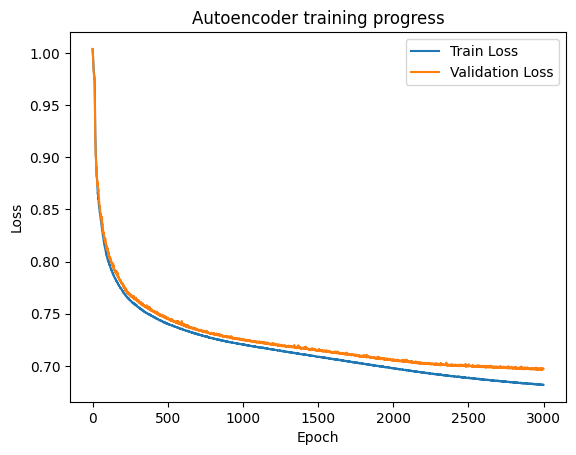

In [3]:
ae_model.train(dl_train=dl_train, dl_val=dl_val, num_epochs=config['train_params']['num_epochs'], plot_loss=True)

In [6]:
from src.ae_utils import save_ae

save_path = config['save_path']

save_ae(ae_model, scaler, save_path)

INFO - Autoencoder saved in ./models/ae_model_saved.pth.


### 3.1. Load AE & Resume Training

The `save_ae`, `load_ae` and `train_ae` functions allow for training to be resumed from the saved data.

INFO - Autoencoder and optimiser set up.
INFO - Autoencoder loaded from ./models/ae_model_saved.pth.
Training model for 1000 epochs: 100%|██████████| 1000/1000 [12:58<00:00,  1.29epoch/s, Train Loss=0.6724, Validation Loss=0.6957]
INFO - Autoencoder training epochs 0 to 1000 completed in 778s.


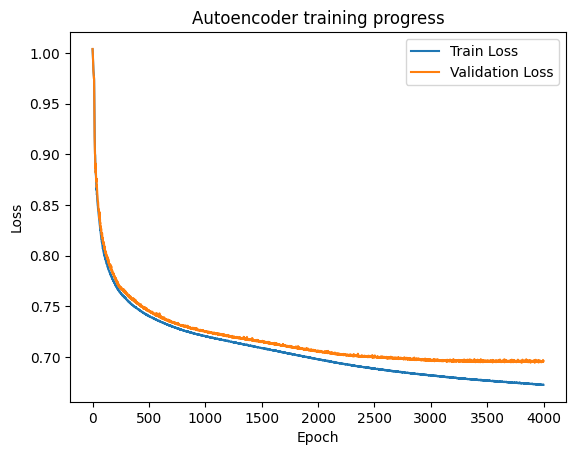

In [8]:
from src.ae_utils import load_ae

ae_model, scaler = load_ae(save_path)

# resume training for an additional 1000 epochs
num_epochs = ae_model.curr_epoch + 1000

ae_model.train(dl_train=dl_train, dl_val=dl_val, num_epochs=num_epochs, plot_loss=True)

In [9]:
save_ae(ae_model, scaler, save_path)

INFO - Autoencoder saved in ./models/ae_model_saved.pth.


### 4. Data Reconstruction and Anomaly Detection with AE
The Tennessee Eastman test dataset has fault-free as well as faulty data to test with.

### 4.1 Load Test Data
There's the fault-free data, and faults no. 1-20. Each set has 500 simulation runs. We will only load 20 runs of each for testing.

We load the saved model, followed by the test data.

In [1]:
from src.general_utils import load_config
from src.ae_utils import load_ae

config = load_config('./configs/config.yaml')
save_path = config['save_path']
ae_model, scaler = load_ae(save_path)

INFO - Configuration loaded from ./configs/config.yaml
INFO - Autoencoder and optimiser set up.
INFO - Autoencoder loaded from ./models/ae_model_saved.pth.


In [2]:
from src.datapipeline import load_inference_data

# modify config.yaml to change number of runs loaded
X_test_df, dl_test = load_inference_data(config, scaler)

Loading test data, this may take a while...


INFO - Faultfree test RData loaded.
INFO - Faulty test RData loaded.
INFO - Test dataframe and dataloader returned, 20 runs for each faultNumber.
INFO - Test dataframe size is (403200, 55).


### 4.2 Process Test Data for Evaluation
Creating the `AE_eval` class object will trigger an inference run on the given test data.

In [3]:
from src.eval_tools import AE_eval

ae_eval = AE_eval(X_test_df, dl_test, ae_model, scaler)

Autoencoder inferencing for 53 batches: 100%|██████████| 53/53 [00:02<00:00, 25.85batch/s]
INFO - Autoencoder inferencing for 53 test batches completed.


Calling the `reconstruction_RMSE()` method populates a dataframe with the RMSE of all test simulation runs.

In [4]:
ae_eval.reconstruction_RMSE()

faultNumber: 100%|██████████| 21/21 [00:59<00:00,  2.84s/it]


,faultNumber,simulationRun,xmeas_1,xmeas_2,xmeas_3,xmeas_4,xmeas_5,xmeas_6,xmeas_7,xmeas_8,...,xmv_2,xmv_3,xmv_4,xmv_5,xmv_6,xmv_7,xmv_8,xmv_9,xmv_10,xmv_11
0,0.0,1.0,0.880089,1.003087,0.925694,0.907644,1.017489,1.016953,0.426612,0.959295,...,0.898315,0.877591,1.006192,0.590311,0.881636,1.024897,1.000829,0.264655,0.971868,1.041640
1,0.0,2.0,0.791371,0.999688,0.850293,0.854301,0.996791,1.012993,0.373188,0.916612,...,0.835365,0.788064,0.957395,0.502607,0.877210,1.030475,0.962912,0.190672,0.983016,1.008679
2,0.0,3.0,0.792839,1.085337,0.868967,0.867859,0.970959,0.983802,0.459200,0.928987,...,0.884623,0.795389,1.032016,0.571718,0.879546,0.977487,1.000270,0.297306,0.989136,1.026241
3,0.0,4.0,0.826583,1.065298,0.880445,0.865911,1.009061,1.021981,0.439997,0.905820,...,0.885976,0.828836,0.968427,0.507255,0.832542,0.998083,0.961719,0.287971,0.981225,0.969403
4,0.0,5.0,0.821180,0.986490,0.882254,0.908796,0.987980,1.001493,0.379872,0.928540,...,0.876636,0.820239,0.946197,0.503354,0.893168,1.022826,1.002401,0.218615,0.954146,0.977718
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
415,20.0,16.0,0.913361,1.052760,0.957471,0.954048,0.993662,1.041146,0.931407,0.995391,...,0.972520,0.909973,0.984693,4.769154,1.012694,1.000100,1.023412,0.569944,1.064683,1.002294
416,20.0,17.0,0.900638,1.098103,0.964945,0.916011,1.031741,1.004140,0.873783,0.983868,...,0.926652,0.897734,0.976432,4.786109,0.951849,0.977040,1.027259,0.476004,1.056296,1.026162
417,20.0,18.0,0.911694,1.114207,0.941790,0.949755,1.013030,1.049410,0.983578,0.977883,...,0.958664,0.911338,0.983964,4.657758,0.972685,0.990367,1.017721,0.529892,1.094599,1.022070
418,20.0,19.0,0.911375,1.090411,0.927493,0.928917,1.002062,1.074637,0.890171,0.958829,...,0.938975,0.913829,0.984918,4.752060,0.948111,1.012444,1.044894,0.607917,1.127797,1.013158


Verify that the fault-free test set has low RMSE for all features. 

The RMSE is calculated on standardised feature values. So we would expect the RMSE to be around 1 or lower.

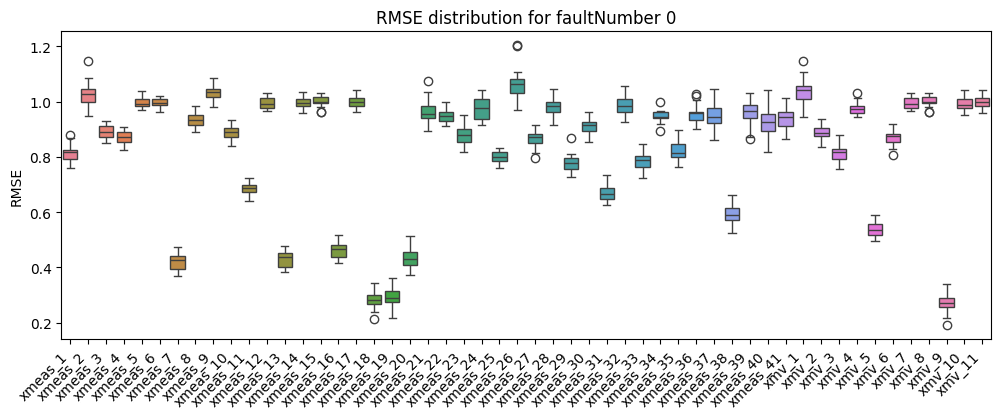

In [5]:
ae_eval.plot_RMSE_distributions(faultNumber=0)

Verify that the reconstructed data follows the general pattern of the test data.

The semi-transparent area show the min-max of the 20 runs.

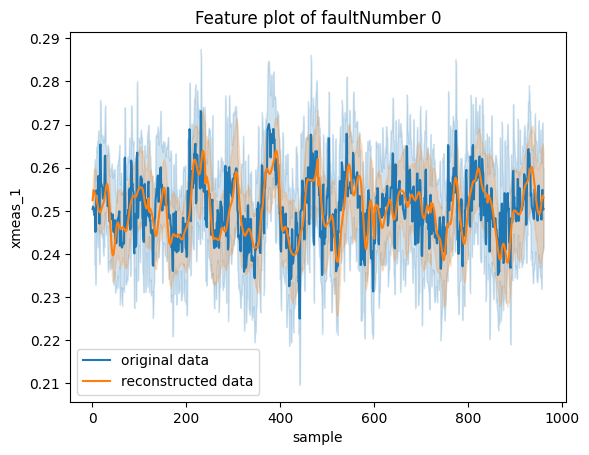

In [6]:
ae_eval.plot_feature(feature='xmeas_1', faultNumber=0)

### 4.3 Results Analysis

For each `faultNumber`, which features have RMSE that exceed a certain threshold value (`highMSEcolumns`)? 

And among the 20 test sample runs, how many sample runs have at least one feature whose RMSE exceeds threshold (`anormCount`)?

In the dataframe below, the columns with the feature names now contain the number of sample runs where that feature's RMSE exceeded the threshold.

In [7]:
high_RMSE = ae_eval.find_high_RMSE(RMSE_threshold=1.4)
high_RMSE

,faultNumber,highMSEcolumns,anormCount,xmeas_1,xmeas_2,xmeas_3,xmeas_4,xmeas_5,xmeas_6,xmeas_7,...,xmv_2,xmv_3,xmv_4,xmv_5,xmv_6,xmv_7,xmv_8,xmv_9,xmv_10,xmv_11
0,0,[],0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,"[xmeas_1, xmeas_3, xmeas_4, xmeas_7, xmeas_8, ...",20,20,0,20,20,0,0,20,...,20,20,20,20,20,0,0,20,0,0
2,2,"[xmeas_3, xmeas_4, xmeas_6, xmeas_7, xmeas_10,...",20,0,6,20,20,0,20,20,...,20,0,20,20,20,0,0,20,0,0
3,3,[],0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,[xmv_10],20,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,20,0
5,5,"[xmeas_20, xmv_11]",20,0,0,0,0,0,0,4,...,0,0,0,5,0,0,0,6,0,20
6,6,"[xmeas_1, xmeas_2, xmeas_3, xmeas_4, xmeas_7, ...",20,20,13,20,19,0,0,20,...,20,20,20,20,20,0,0,20,20,20
7,7,"[xmeas_1, xmeas_3, xmeas_4, xmeas_7, xmeas_8, ...",20,20,2,20,20,0,0,20,...,20,20,20,20,20,0,0,20,20,0
8,8,"[xmeas_1, xmeas_3, xmeas_4, xmeas_7, xmeas_8, ...",20,20,5,20,20,0,4,20,...,20,20,19,20,20,0,0,20,19,0
9,9,[],0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


#### Quick Summary
So in our limited number of test sets, we can see that:
- There are no false positives; none of the fault-free cases are flagged as anormalous.
- `faultNumber` 3, 9 and 15 does not get detected by this technique, while `faultNumber` 16 may get flagged in a limited number of instances.
- There may be some false negatives for `faultNumber` 10.
- The accuracies for the other `faultNumber`s are 100%, in some cases helped by the presence of multiple features where anormalies can be detected.

#### Deeper Inspection to Understand Points of Failures

Visually inspect an example to see what the RMSE across features look like. Let's look at `faultNumber` 10 where there are some false negatives.

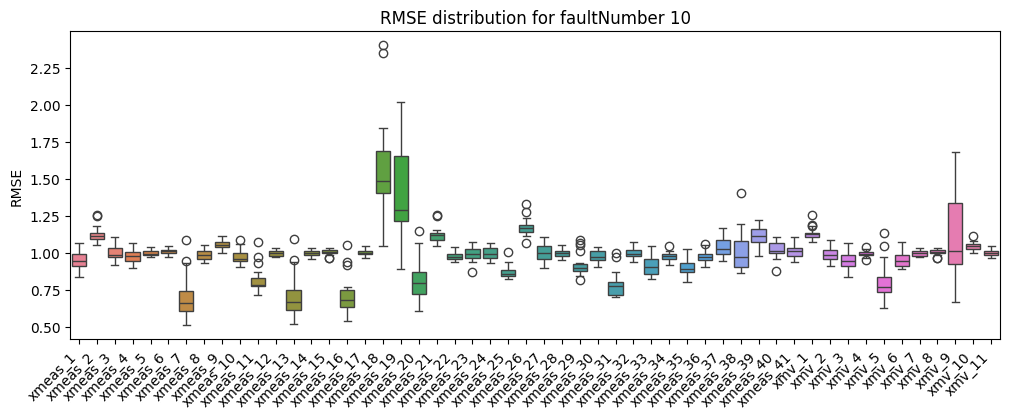

In [13]:
ae_eval.plot_RMSE_distributions(faultNumber=10)

Visualising the RMSE distributions allows us to quickly see that the indicative features are `xmeas_18`, `xmeas_19` and `xmv_9`. But because all three features have RMSE distributions where the lower ends are below the threshold value, false negatives can occur.

For a deeper understanding of why the RMSE values are not high even, we have to look at the time-series features themselves.

Visually inspect the time-series to see how the data is anomalous. Compare that with the fault-free case.

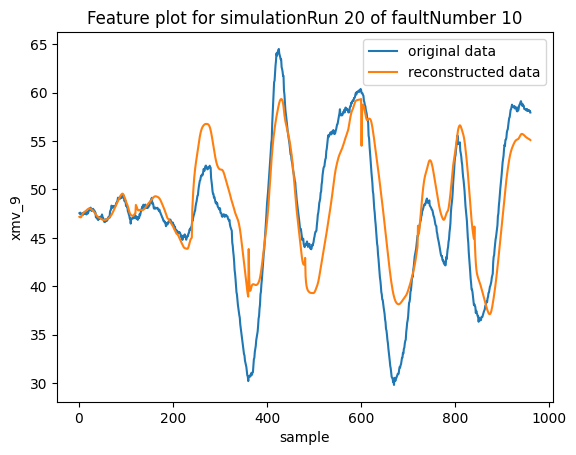

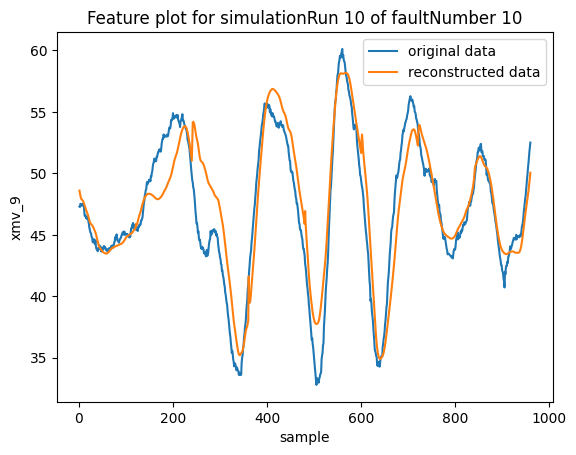

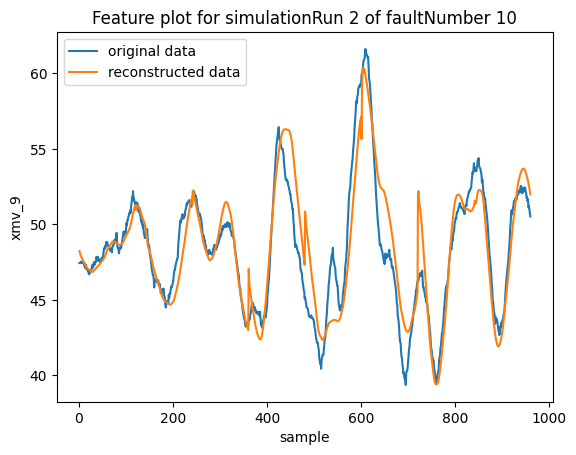

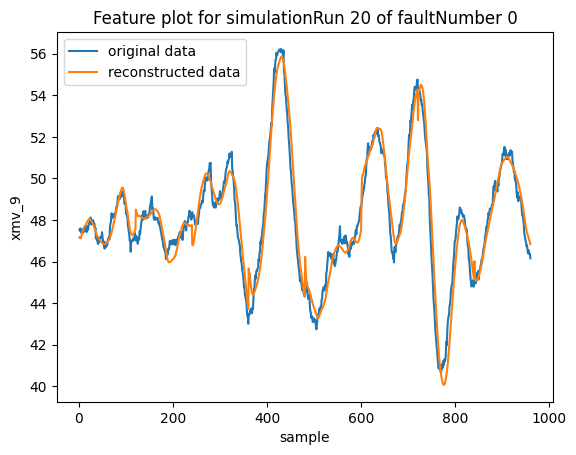

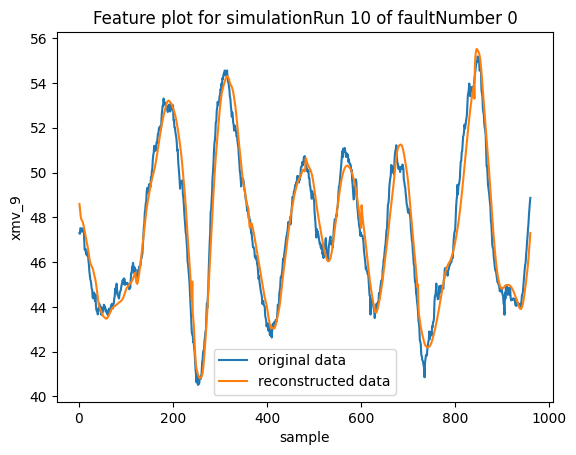

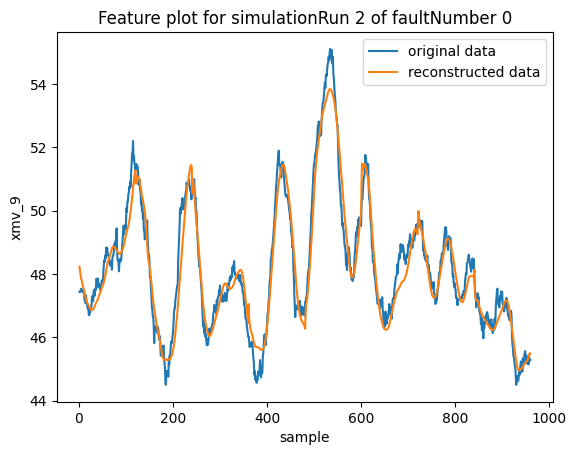

In [14]:
feature = 'xmv_9'

ae_eval.plot_feature(feature=feature, faultNumber=10, simulationRun=20)
ae_eval.plot_feature(feature=feature, faultNumber=10, simulationRun=10)
ae_eval.plot_feature(feature=feature, faultNumber=10, simulationRun=2)
ae_eval.plot_feature(feature=feature, faultNumber=0, simulationRun=20)
ae_eval.plot_feature(feature=feature, faultNumber=0, simulationRun=10)
ae_eval.plot_feature(feature=feature, faultNumber=0, simulationRun=2)

From a few samples, we can see that `xmv_9` does not present any obviously anomalous behaviours on its own for `faultNumber` 10. The reconstructed data does seem to follow the time-series more poorly than the fault-free case, and some glitches are present (probably caused by correlation effects from other anomalous features). Better to look at other features.

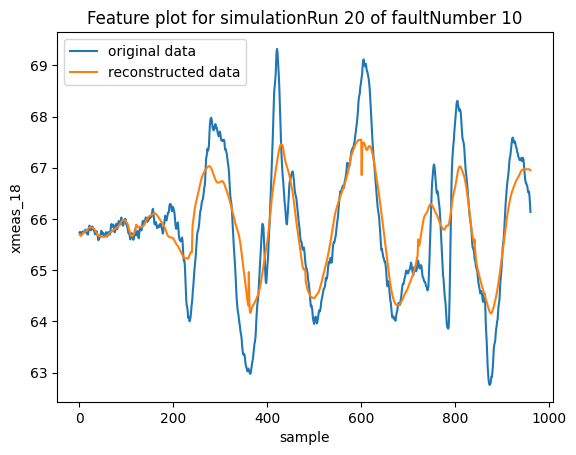

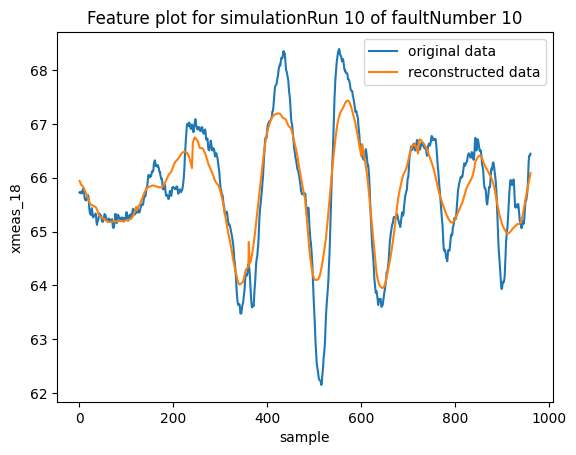

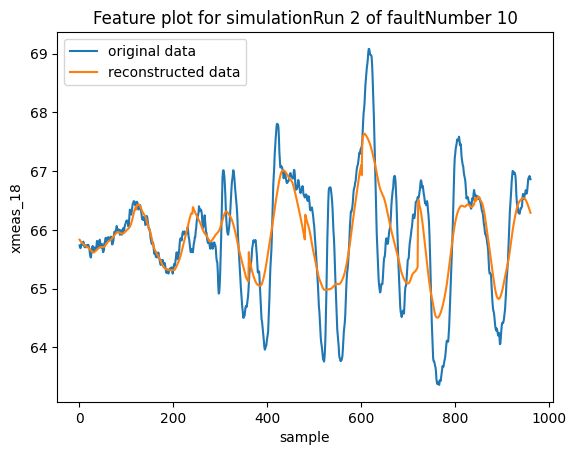

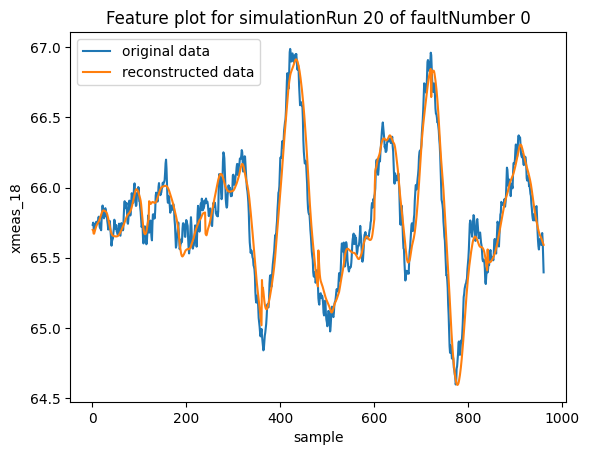

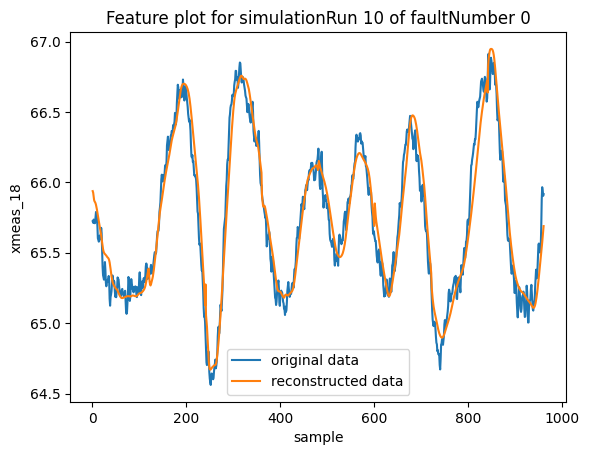

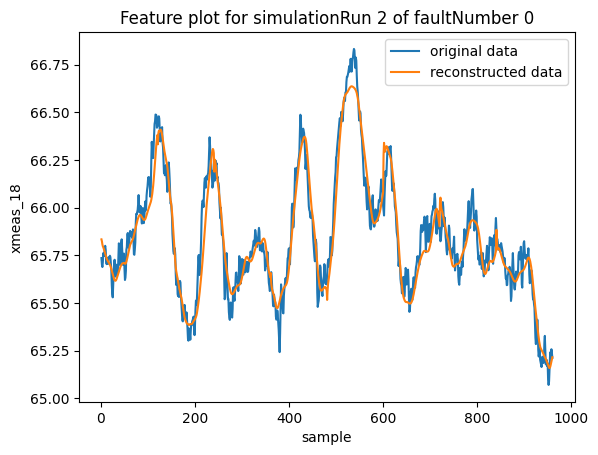

In [16]:
feature = 'xmeas_18'

ae_eval.plot_feature(feature=feature, faultNumber=10, simulationRun=20)
ae_eval.plot_feature(feature=feature, faultNumber=10, simulationRun=10)
ae_eval.plot_feature(feature=feature, faultNumber=10, simulationRun=2)
ae_eval.plot_feature(feature=feature, faultNumber=0, simulationRun=20)
ae_eval.plot_feature(feature=feature, faultNumber=0, simulationRun=10)
ae_eval.plot_feature(feature=feature, faultNumber=0, simulationRun=2)

From `xmeas_18`, we can see that the general shape of the time-series are not very different, but the amplitude of the signals is much larger in the faulty case. This is a good indicator of anomaly in thte signal, but unfortunately the LSTM autoencoder is able to reconstruct the signal with high enough fidelity to make anomaly detection in this case imperfect.

___
## Summary and Conclusions

- The LSTM autoencoder is a viable way to detect anomalies in multi-dimensionala time-series data. 

- From the feature plots, we can tell that the autoencoder is unable to reproduce all the noise and random high frequency variations even in the fault-free data, and behaves somewhat like a low-pass filter. This is not unexpected as the embeddings would only retain the salient features in the data, and this should not include random fluctuations. But this also prevents us from detecting anomalies that produce lower reproduction RMSE values via this approach.

- The LSTM autoencoder technique has difficulties picking up some forms of faults or anomalies. From very limited inspection of the time-series data, one type of anomaly that is difficult to identify could be a simple change in signal amplitude.

- No hyperparameter or detection threshold tuning has been performed - it's quite possible that the results can be improved. 